# Tutorial 3: Artificial Neural Networks (ANN) with PyTorch

This notebook covers the implementation of ANNs using PyTorch for Rheumatoid Arthritis classification. We will:
1. Define a flexible ANN architecture.
2. Experiment with different depths and activation functions.
3. Compare optimizers (SGD, Adam, RMSprop).
4. Implement Early Stopping and Regularization to handle overfitting.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ensure reproducibility
torch.manual_seed(42)

# Convert data to PyTorch tensors
# Assuming X_train, X_test, y_train, y_test are already available from your previous steps
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# Create DataLoaders
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [ ]:
class FlexibleANN(nn.Module):
    def __init__(self, input_size, layers, activation='relu', dropout_rate=0.0):
        super(FlexibleANN, self).__init__()
        self.hidden_layers = nn.ModuleList()

        # Select activation function
        if activation == 'relu':
            self.act = nn.ReLU()
        elif activation == 'tanh':
            self.act = nn.Tanh()
        elif activation == 'sigmoid':
            self.act = nn.Sigmoid()

        current_dim = input_size
        for h in layers:
            self.hidden_layers.append(nn.Linear(current_dim, h))
            if dropout_rate > 0:
                self.hidden_layers.append(nn.Dropout(dropout_rate))
            current_dim = h

        self.output_layer = nn.Linear(current_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        for layer in self.hidden_layers:
            if isinstance(layer, nn.Linear):
                x = self.act(layer(x))
            else:
                x = layer(x) # Dropout
        return self.sigmoid(self.output_layer(x))

Early stopping at epoch 64


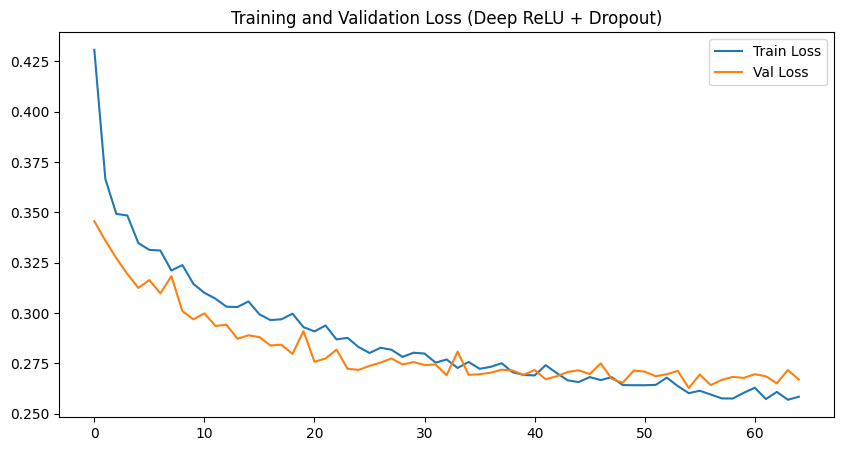

In [ ]:
def train_model(model, train_loader, test_loader, optimizer, epochs=100, patience=10):
    criterion = nn.BCELoss()
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    trigger_times = 0

    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        train_losses.append(np.mean(batch_losses))

        # Validation
        model.eval()
        with torch.no_grad():
            val_pred = model(X_test_t)
            val_loss = criterion(val_pred, y_test_t).item()
            val_losses.append(val_loss)

        # Early Stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            trigger_times = 0
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print(f'Early stopping at epoch {epoch}')
                break

    return train_losses, val_losses

# Experiment 1: Deep Architecture with ReLU
input_dim = X_train_t.shape[1]
model_deep = FlexibleANN(input_dim, [128, 64, 32], activation='relu', dropout_rate=0.2)
opt_adam = optim.Adam(model_deep.parameters(), lr=0.001)

t_losses, v_losses = train_model(model_deep, train_loader, test_loader, opt_adam)

# Plotting Curves
plt.figure(figsize=(10, 5))
plt.plot(t_losses, label='Train Loss')
plt.plot(v_losses, label='Val Loss')
plt.title('Training and Validation Loss (Deep ReLU + Dropout)')
plt.legend()
plt.show()

In [ ]:
# Task 2 & 3: Experimenting with Architectures and Optimizers

architectures = [
    {'name': 'Simple (8,)', 'layers': [8]},
    {'name': 'Medium (64, 32)', 'layers': [64, 32]},
    {'name': 'Deep (128, 64, 32)', 'layers': [128, 64, 32]}
]

optimizers_to_test = [
    ('Adam', optim.Adam),
    ('SGD', optim.SGD),
    ('RMSprop', optim.RMSprop)
]

results = []
input_dim = X_train_t.shape[1]

for arch in architectures:
    for opt_name, opt_class in optimizers_to_test:
        print(f"Training Architecture: {arch['name']} with Optimizer: {opt_name}")

        # Initialize model
        model = FlexibleANN(input_dim, arch['layers'], activation='relu', dropout_rate=0.1)

        # Initialize optimizer
        if opt_name == 'SGD':
            optimizer = opt_class(model.parameters(), lr=0.01, momentum=0.9)
        else:
            optimizer = opt_class(model.parameters(), lr=0.001)

        # Train
        t_loss, v_loss = train_model(model, train_loader, test_loader, optimizer, epochs=50, patience=5)

        # Evaluate final accuracy
        model.eval()
        with torch.no_grad():
            val_pred_probs = model(X_test_t)
            val_pred_class = (val_pred_probs > 0.5).float()
            accuracy = (val_pred_class == y_test_t).float().mean().item()

        results.append({
            'Architecture': arch['name'],
            'Optimizer': opt_name,
            'Final_Val_Loss': v_loss[-1],
            'Accuracy': accuracy
        })

# Display Results Table
results_df = pd.DataFrame(results)
print("\n--- Comparison Table ---")
print(results_df)

Training Architecture: Simple (8,) with Optimizer: Adam
Training Architecture: Simple (8,) with Optimizer: SGD
Early stopping at epoch 38
Training Architecture: Simple (8,) with Optimizer: RMSprop
Early stopping at epoch 28
Training Architecture: Medium (64, 32) with Optimizer: Adam
Early stopping at epoch 41
Training Architecture: Medium (64, 32) with Optimizer: SGD
Training Architecture: Medium (64, 32) with Optimizer: RMSprop
Early stopping at epoch 43
Training Architecture: Deep (128, 64, 32) with Optimizer: Adam
Early stopping at epoch 47
Training Architecture: Deep (128, 64, 32) with Optimizer: SGD
Early stopping at epoch 29
Training Architecture: Deep (128, 64, 32) with Optimizer: RMSprop
Early stopping at epoch 45

--- Comparison Table ---
         Architecture Optimizer  Final_Val_Loss  Accuracy
0         Simple (8,)      Adam        0.329795  0.855294
1         Simple (8,)       SGD        0.329031  0.856176
2         Simple (8,)   RMSprop        0.344162  0.844706
3     Medi

Training with activation: relu
Early stopping at epoch 38
Training with activation: tanh
Training with activation: sigmoid


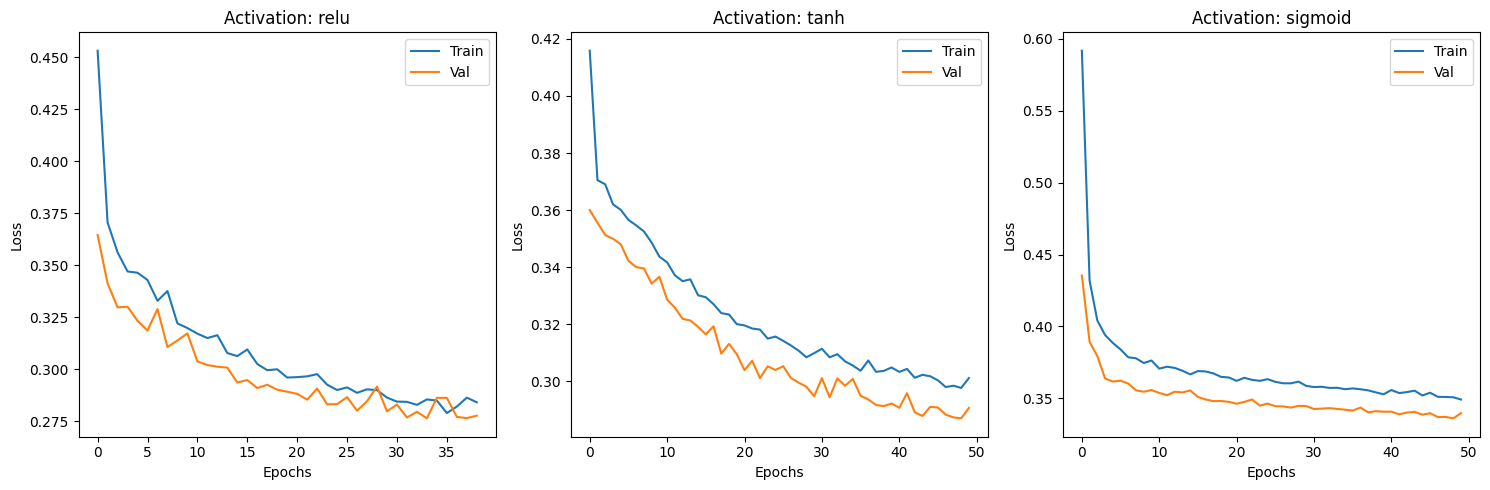


--- Interpretation of Results ---
1. Overfitting: If Train Loss continues to decrease while Val Loss starts to increase or plateaus significantly higher.
2. Underfitting: If both Train and Val Loss remain high or stop decreasing before reaching a low value.
3. Well-fitted: Both losses decrease and converge closely together.
By using Early Stopping and Dropout (Regularization), we mitigate the risk of overfitting observed in deep architectures.


In [ ]:
# Task 2: Experiment with different activation functions
activations = ['relu', 'tanh', 'sigmoid']
plt.figure(figsize=(15, 5))

for i, act in enumerate(activations):
    print(f"Training with activation: {act}")
    model = FlexibleANN(input_dim, [64, 32], activation=act, dropout_rate=0.1)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    t_loss, v_loss = train_model(model, train_loader, test_loader, optimizer, epochs=50, patience=5)

    plt.subplot(1, 3, i+1)
    plt.plot(t_loss, label='Train')
    plt.plot(v_loss, label='Val')
    plt.title(f'Activation: {act}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

plt.tight_layout()
plt.show()

# Task 4: Interpretation Guide
print("\n--- Interpretation of Results ---")
print("1. Overfitting: If Train Loss continues to decrease while Val Loss starts to increase or plateaus significantly higher.")
print("2. Underfitting: If both Train and Val Loss remain high or stop decreasing before reaching a low value.")
print("3. Well-fitted: Both losses decrease and converge closely together.")
print("By using Early Stopping and Dropout (Regularization), we mitigate the risk of overfitting observed in deep architectures.")

In [ ]:
# Task 2 & 3: Experimenting with Architectures and Optimizers

architectures = [
    {'name': 'Simple (8,)', 'layers': [8]},
    {'name': 'Medium (64, 32)', 'layers': [64, 32]},
    {'name': 'Deep (128, 64, 32)', 'layers': [128, 64, 32]}
]

optimizers_to_test = [
    ('Adam', optim.Adam),
    ('SGD', optim.SGD),
    ('RMSprop', optim.RMSprop)
]

results = []

for arch in architectures:
    for opt_name, opt_class in optimizers_to_test:
        print(f"Training Architecture: {arch['name']} with Optimizer: {opt_name}")

        # Initialize model
        model = FlexibleANN(input_dim, arch['layers'], activation='relu', dropout_rate=0.1)

        # Initialize optimizer
        if opt_name == 'SGD':
            optimizer = opt_class(model.parameters(), lr=0.01, momentum=0.9)
        else:
            optimizer = opt_class(model.parameters(), lr=0.001)

        # Train
        t_loss, v_loss = train_model(model, train_loader, test_loader, optimizer, epochs=50, patience=5)

        # Evaluate final accuracy
        model.eval()
        with torch.no_grad():
            y_pred_probs = model(X_test_t)
            y_pred_class = (y_pred_probs > 0.5).float()
            accuracy = (y_pred_class == y_test_t).float().mean().item()

        results.append({
            'Architecture': arch['name'],
            'Optimizer': opt_name,
            'Final_Val_Loss': v_loss[-1],
            'Accuracy': accuracy
        })

# Display Results
results_df = pd.DataFrame(results)
print("\nComparison Table:")
print(results_df)

Training Architecture: Simple (8,) with Optimizer: Adam
Early stopping at epoch 49
Training Architecture: Simple (8,) with Optimizer: SGD
Early stopping at epoch 33
Training Architecture: Simple (8,) with Optimizer: RMSprop
Early stopping at epoch 39
Training Architecture: Medium (64, 32) with Optimizer: Adam
Early stopping at epoch 49
Training Architecture: Medium (64, 32) with Optimizer: SGD
Training Architecture: Medium (64, 32) with Optimizer: RMSprop
Early stopping at epoch 35
Training Architecture: Deep (128, 64, 32) with Optimizer: Adam
Early stopping at epoch 20
Training Architecture: Deep (128, 64, 32) with Optimizer: SGD
Early stopping at epoch 36
Training Architecture: Deep (128, 64, 32) with Optimizer: RMSprop
Early stopping at epoch 28

Comparison Table:
         Architecture Optimizer  Final_Val_Loss  Accuracy
0         Simple (8,)      Adam        0.339825  0.846765
1         Simple (8,)       SGD        0.327553  0.858824
2         Simple (8,)   RMSprop        0.339597 

Training with activation: relu
Early stopping at epoch 34
Training with activation: tanh
Training with activation: sigmoid


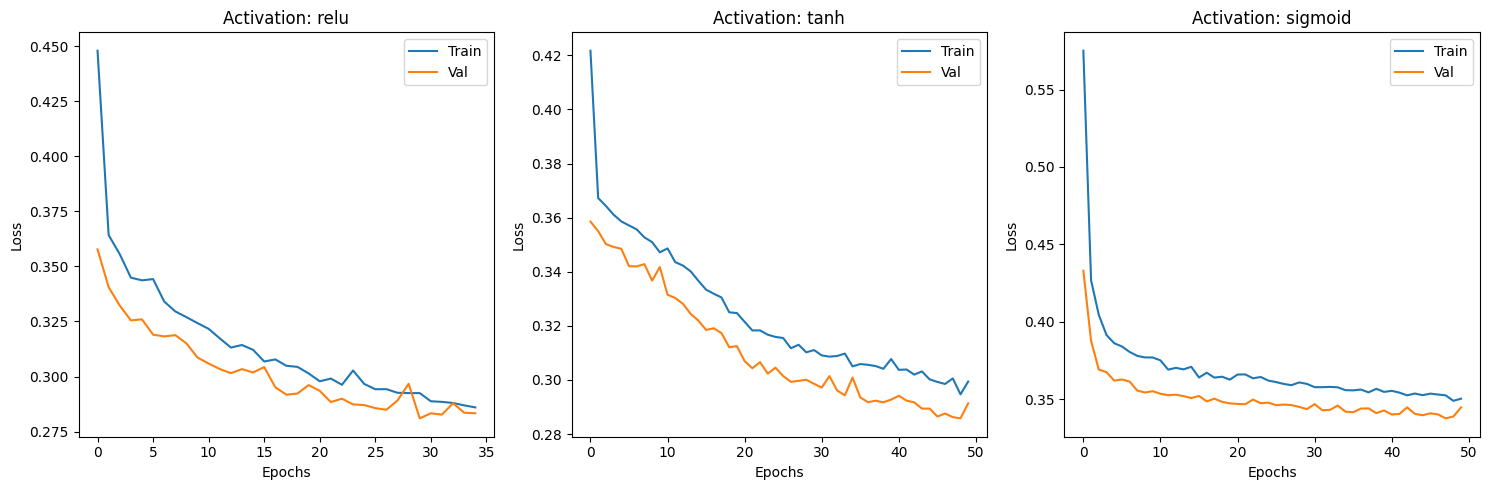


--- Interpretation Guide ---
1. Overfitting: If Train Loss continues to decrease while Val Loss starts to increase.
2. Underfitting: If both Train and Val Loss remain high or stop decreasing prematurely.
3. Well-fitted: Both losses decrease and stabilize near each other.
Early stopping and Dropout implemented above are key regularization techniques used here to prevent overfitting.


In [ ]:
# Task 2: Experiment with different activation functions
activations = ['relu', 'tanh', 'sigmoid']
plt.figure(figsize=(15, 5))

for i, act in enumerate(activations):
    print(f"Training with activation: {act}")
    model = FlexibleANN(input_dim, [64, 32], activation=act, dropout_rate=0.1)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    t_loss, v_loss = train_model(model, train_loader, test_loader, optimizer, epochs=50, patience=5)

    plt.subplot(1, 3, i+1)
    plt.plot(t_loss, label='Train')
    plt.plot(v_loss, label='Val')
    plt.title(f'Activation: {act}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

plt.tight_layout()
plt.show()

# Task 4: Interpretation
print("\n--- Interpretation Guide ---")
print("1. Overfitting: If Train Loss continues to decrease while Val Loss starts to increase.")
print("2. Underfitting: If both Train and Val Loss remain high or stop decreasing prematurely.")
print("3. Well-fitted: Both losses decrease and stabilize near each other.")
print("Early stopping and Dropout implemented above are key regularization techniques used here to prevent overfitting.")